In [ ]:
!pip install tensorflow_gnn --pre
!pip install tensorflow_ranking

In [ ]:
# Install standard modules

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_gnn as tfgnn
import tensorflow_ranking as tfr
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loaded 5027 squamous cell carcinoma images from Google Drive.


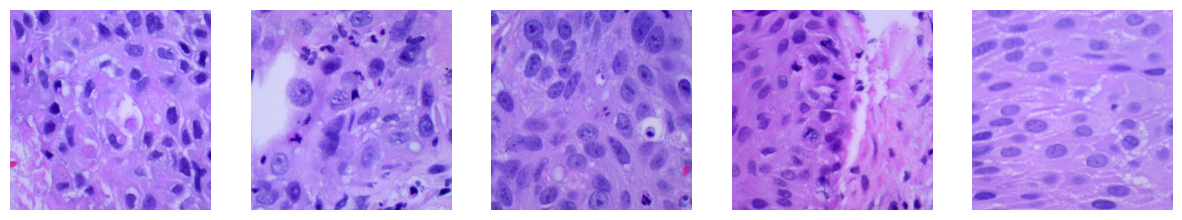

In [ ]:
# Step 1: Import necessary libraries
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Define the path to your dataset folder in Google Drive
dataset_path = '/content/drive/MyDrive/Colab Notebooks/GNN/Codes/Data'
scc_folder = os.path.join(dataset_path, 'lung_scc')  # Adjust folder name if needed

# Step 3: Initialize a list to store the paths of squamous cell carcinoma images
scc_images = []

# Step 4: Walk through the squamous cell carcinoma folder and find images

for root, dirs, files in os.walk(scc_folder):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):  # Specify image formats
            scc_images.append(os.path.join(root, file))

print(f"Loaded {len(scc_images)} squamous cell carcinoma images from Google Drive.")

# Step 5: Display the first 5 images from the dataset to verify
plt.figure(figsize=(15, 15))
for i in range(min(5, len(scc_images))):  # Display the first 5 images as an example
    image = Image.open(scc_images[i])
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.axis('off')
plt.show()



In [ ]:
import gc
gc.collect()

89

In [ ]:
def image_to_graph(image_path):
    img = Image.open(image_path).resize((224, 224))  # Resize image
    img_array = np.array(img) / 255.0  # Normalize image to [0, 1]

    height, width, _ = img_array.shape
    num_nodes = height * width

    # Node features: flatten the image into nodes
    node_features = img_array.reshape(-1, 3)  # Each pixel is a node with 3 color channels

    # Create a limited number of edges (4-connected neighborhood)
    edge_indices = []
    for i in range(height):
        for j in range(width):
            node_idx = i * width + j
            if i > 0:  # Up
                edge_indices.append([node_idx, (i-1) * width + j])
            if i < height - 1:  # Down
                edge_indices.append([node_idx, (i+1) * width + j])
            if j > 0:  # Left
                edge_indices.append([node_idx, i * width + (j-1)])
            if j < width - 1:  # Right
                edge_indices.append([node_idx, i * width + (j+1)])

    edge_index = np.array(edge_indices).T

    return node_features, edge_index

# Convert all images to graph data with limited edges
graph_data_list = [image_to_graph(img) for img in scc_images]


In [ ]:
# Generate labels (1 for SCC, 0 for Non-SCC) based on your specific labeling logic
labels = np.array([1 if 'positive' in img else 0 for img in scc_images])  # Adjust logic as needed

# Step 4: Prepare the dataset
X = np.array([data[0] for data in graph_data_list])  # Extract node features
y = np.array(labels)  # Your labels

# Step 5: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Step 6: Define a function to convert your data to a TensorFlow dataset
def create_tf_dataset(X, y, batch_size=32):
    return tf.data.Dataset.from_tensor_slices((X, y)).batch(batch_size)

train_dataset = create_tf_dataset(X_train, y_train)
test_dataset = create_tf_dataset(X_test, y_test)

In [ ]:
# Step 7: Define Graph Conv Layer
class GraphConvLayer(tf.keras.layers.Layer):
    def __init__(self, num_outputs):
        super(GraphConvLayer, self).__init__()
        self.num_outputs = num_outputs

    def call(self, inputs):
        node_features, edge_index = inputs
        num_nodes = tf.shape(node_features)[0]

        # Initialize output features
        output_features = tf.zeros((num_nodes, self.num_outputs))

        for edge in edge_index.numpy().T:
            i, j = edge
            output_features[j] += node_features[i]  # Aggregate messages from neighbors

        return output_features


In [ ]:
# Step 8: Define Simple GNN Model
class SimpleGNNModel(tf.keras.Model):
    def __init__(self):
        super(SimpleGNNModel, self).__init__()
        self.graph_conv1 = GraphConvLayer(16)
        self.graph_conv2 = GraphConvLayer(32)
        self.dense = tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification

    def call(self, inputs):
        node_features, edge_index = inputs
        x = self.graph_conv1([node_features, edge_index])
        x = tf.nn.relu(x)
        x = self.graph_conv2([x, edge_index])
        x = tf.nn.relu(x)
        x = tf.reduce_mean(x, axis=0)  # Aggregate node features
        return self.dense(x)

In [ ]:
# Step 9: Early Stopping, Model Checkpointing, and Learning Rate Scheduler
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5', save_best_only=True, monitor='val_loss', mode='min'
)

lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-4 * 10**(epoch / 20)
)

In [ ]:
# Step 10: Compile the model
model = SimpleGNNModel()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Step 11: Train the model
model.fit(train_dataset,
          validation_data=test_dataset,
          epochs=30,
          callbacks=[early_stopping, checkpoint_callback, lr_schedule])


In [ ]:
# Step 12: Make predictions on the test set
y_pred_probs = model.predict(test_dataset)
y_pred_classes = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

In [ ]:
# Step 13: Evaluate model performance
print("Model Evaluation:")
print(classification_report(y_test, y_pred_classes))

In [ ]:
# Step 14: Calculate and display test accuracy
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}')


In [ ]:
# Step 15: Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-SCC', 'SCC'], yticklabels=['Non-SCC', 'SCC'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()